# Notebook 16 — MJO Three-Way Comparison (RMM vs Supervised vs SSL)
**Project:** ENSO-BSISO SSL — MJO Extension  
**Author:** Jiayi (jh9141@nyu.edu)

The capstone notebook of the MJO extension. Mirrors BSISO nb09 + nb10b structure, comparing three 2D representations of MJO state:

| ID | Object | Source | Dates |
|----|--------|--------|-------|
| `rmm` | Wheeler & Hendon RMM index (conventional) | `rmm_labels.csv` — `atan2(RMM2, RMM1)` | ~16,425 days |
| `sup` | Supervised 2D encoder (nb14) | `MJO/results/sup/embeddings.npy` | ~16,425 days |
| `ssl` | SSL temporal 2D encoder (nb15) | `MJO/results/ssl/embeddings.npy` | ~16,245 days (after edge drops) |

## What this notebook produces

1. **Lag circular correlation** between all 3 pairs (τ ∈ [−30, +30] d), Jammalamadaka & SenGupta ρ_c, within-year pairs
2. **Per-phase ENSO displacement** comparison (3 reps × 8 phases)
3. **Phase composite longitude profiles** of OLR' for each representation
4. **EN−LN difference composites** — the key visual showing whether SSL captures ENSO modulation more strongly than RMM/sup
5. **Auto-generated comparison report** → `MJO/results/mjo_comparison_report.txt`

## Key scientific question

Does the SSL advantage observed in BSISO (z_SSL=14.55 vs z_sup=2.53) generalize to MJO?  
If yes → the SSL advantage is a general property of temporal contrastive learning on intraseasonal data, not specific to boreal summer monsoon dynamics.

---

## Cell 1 — Mount Drive + Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR        = f'{PROJECT_DIR}/MJO'
RAW_DIR        = f'{MJO_DIR}/data/raw'
PROCESSED_DIR  = f'{MJO_DIR}/data/processed'
RESULTS_DIR    = f'{MJO_DIR}/results'
OUT_DIR        = f'{RESULTS_DIR}/comparison'
os.makedirs(OUT_DIR, exist_ok=True)

# Input files
RMM_LABELS_FILE     = f'{RAW_DIR}/rmm_labels.csv'                  # rmm + ENSO
MJO_LABELS_FILE     = f'{PROCESSED_DIR}/labels_aligned_mjo.csv'    # aligned to X_MJO
SSL_LABELS_FILE     = f'{PROCESSED_DIR}/labels_aligned_mjo_bp20_90.csv'  # aligned to SSL
X_FILE              = f'{PROCESSED_DIR}/X_MJO.npy'
LON_FILE            = f'{PROCESSED_DIR}/longitudes_mjo.npy'
SUP_EMB_FILE        = f'{RESULTS_DIR}/sup/embeddings.npy'
SSL_EMB_FILE        = f'{RESULTS_DIR}/ssl/embeddings.npy'

for f in [RMM_LABELS_FILE, MJO_LABELS_FILE, SSL_LABELS_FILE,
          X_FILE, LON_FILE, SUP_EMB_FILE, SSL_EMB_FILE]:
    print(f'  {"OK" if os.path.exists(f) else "MISSING":<8s}  {f.replace(PROJECT_DIR, "...")}')
print('\nDrive mounted.')

Mounted at /content/drive
  OK        .../MJO/data/raw/rmm_labels.csv
  OK        .../MJO/data/processed/labels_aligned_mjo.csv
  OK        .../MJO/data/processed/labels_aligned_mjo_bp20_90.csv
  OK        .../MJO/data/processed/X_MJO.npy
  OK        .../MJO/data/processed/longitudes_mjo.npy
  OK        .../MJO/results/sup/embeddings.npy
  OK        .../MJO/results/ssl/embeddings.npy

Drive mounted.


## Cell 2 — Load All Three Representations

Build `theta_rmm`, `theta_sup`, `theta_ssl` and their date indices.  
Note on **SSL orientation:** if needed, negate z₂ (as BSISO nb09 did) so SSL traversal direction matches RMM/sup. We'll check both signs and pick the one with positive ρ_c(rmm, ssl; τ=0).

In [2]:
# --- RMM (conventional) ---
df_rmm = pd.read_csv(RMM_LABELS_FILE, parse_dates=['date'])
df_rmm['date'] = df_rmm['date'].dt.normalize()

# --- Supervised: dates from MJO_LABELS_FILE (aligned to X_MJO) ---
df_sup = pd.read_csv(MJO_LABELS_FILE, parse_dates=['date'])
df_sup['date'] = df_sup['date'].dt.normalize()
emb_sup = np.load(SUP_EMB_FILE)
assert len(emb_sup) == len(df_sup), f'sup mismatch: {len(emb_sup)} vs {len(df_sup)}'

# --- SSL: dates from SSL_LABELS_FILE (subset after edge drops) ---
df_ssl = pd.read_csv(SSL_LABELS_FILE, parse_dates=['date'])
df_ssl['date'] = df_ssl['date'].dt.normalize()
emb_ssl = np.load(SSL_EMB_FILE)
assert len(emb_ssl) == len(df_ssl), f'ssl mismatch: {len(emb_ssl)} vs {len(df_ssl)}'

# Restrict RMM to the dates we actually have ERA5 for (intersection with sup dates)
df_rmm = df_rmm[df_rmm['date'].isin(df_sup['date'])].reset_index(drop=True)
df_rmm = df_rmm.sort_values('date').reset_index(drop=True)

# Reorder df_sup to match df_rmm date order (should already be sorted)
df_sup = df_sup.sort_values('date').reset_index(drop=True)

# --- Compute angles ---
theta_rmm = np.arctan2(df_rmm['rmm2'].values, df_rmm['rmm1'].values)
theta_sup = np.arctan2(emb_sup[:, 1], emb_sup[:, 0])

# SSL orientation check: try both signs, keep the one with positive ρ_c(rmm, ssl; τ=0)
def circular_mean(theta):
    return np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))

def circular_corr(t1, t2):
    if len(t1) < 5: return np.nan
    s1 = np.sin(t1 - circular_mean(t1))
    s2 = np.sin(t2 - circular_mean(t2))
    den = np.sqrt(np.sum(s1**2) * np.sum(s2**2))
    return float(np.sum(s1 * s2) / den) if den > 0 else 0.0

# Align SSL with RMM on common dates for orientation check
common_ssl_rmm = df_ssl['date'].isin(df_rmm['date'])
df_ssl_common  = df_ssl[common_ssl_rmm].reset_index(drop=True)
emb_ssl_common = emb_ssl[common_ssl_rmm.values]
date_to_rmm_idx = {d: i for i, d in enumerate(df_rmm['date'].values)}
rmm_idx_for_ssl = np.array([date_to_rmm_idx[d] for d in df_ssl_common['date'].values])

theta_ssl_pos = np.arctan2( emb_ssl_common[:, 1], emb_ssl_common[:, 0])
theta_ssl_neg = np.arctan2(-emb_ssl_common[:, 1], emb_ssl_common[:, 0])
rho_pos = circular_corr(theta_rmm[rmm_idx_for_ssl], theta_ssl_pos)
rho_neg = circular_corr(theta_rmm[rmm_idx_for_ssl], theta_ssl_neg)

if rho_neg > rho_pos:
    print(f'SSL orientation flipped (z₂ negated): ρ_c(rmm,ssl;0) = {rho_neg:.3f}  vs  {rho_pos:.3f} unflipped')
    theta_ssl = np.arctan2(-emb_ssl[:, 1], emb_ssl[:, 0])
    SSL_FLIP = True
else:
    print(f'SSL orientation kept:                  ρ_c(rmm,ssl;0) = {rho_pos:.3f}  vs  {rho_neg:.3f} flipped')
    theta_ssl = np.arctan2( emb_ssl[:, 1], emb_ssl[:, 0])
    SSL_FLIP = False

# Date indices for downstream
dates_rmm = pd.DatetimeIndex(df_rmm['date'].values)
dates_sup = pd.DatetimeIndex(df_sup['date'].values)
dates_ssl = pd.DatetimeIndex(df_ssl['date'].values)

print(f'\nrmm: {len(theta_rmm)} days  {dates_rmm[0].date()} → {dates_rmm[-1].date()}')
print(f'sup: {len(theta_sup)} days  {dates_sup[0].date()} → {dates_sup[-1].date()}')
print(f'ssl: {len(theta_ssl)} days  {dates_ssl[0].date()} → {dates_ssl[-1].date()}')

SSL orientation kept:                  ρ_c(rmm,ssl;0) = 0.100  vs  -0.100 flipped

rmm: 16436 days  1979-01-01 → 2023-12-31
sup: 16436 days  1979-01-01 → 2023-12-31
ssl: 16256 days  1979-04-01 → 2023-10-02


## Cell 3 — Lag Circular Correlation Helpers (same as nb09)

In [3]:
def precompute_pairs(dates_A, dates_B, max_lag=30):
    """Within-year pair indices (ia, ib) for every lag."""
    date_to_idx_B = {d: i for i, d in enumerate(dates_B)}
    lags = np.arange(-max_lag, max_lag + 1)
    pairs = {}
    for tau in lags:
        ia, ib = [], []
        for i, d in enumerate(dates_A):
            d_shift = d + pd.Timedelta(days=int(tau))
            if d_shift.year != d.year: continue
            if d_shift in date_to_idx_B:
                ia.append(i); ib.append(date_to_idx_B[d_shift])
        pairs[tau] = (np.array(ia, dtype=int), np.array(ib, dtype=int))
    return lags, pairs

def lag_corr_from_pairs(theta_A, theta_B, lags, pairs, min_pairs=30):
    rho     = np.full(len(lags), np.nan)
    n_pairs = np.zeros(len(lags), dtype=int)
    for k, tau in enumerate(lags):
        ia, ib = pairs[tau]
        if len(ia) < min_pairs: continue
        n_pairs[k] = len(ia)
        rho[k] = circular_corr(theta_A[ia], theta_B[ib])
    return rho, n_pairs

def permutation_null_fast(theta_A, theta_B, dates_B, lags, pairs,
                           n_perm=200, quantile=0.95, rng=None):
    if rng is None: rng = np.random.default_rng(42)
    years_B = pd.DatetimeIndex(dates_B).year
    year_groups = {}
    for i, y in enumerate(years_B):
        year_groups.setdefault(y, []).append(i)
    year_groups = {y: np.array(idx) for y, idx in year_groups.items()}

    null_vals = []
    for _ in range(n_perm):
        theta_B_perm = theta_B.copy()
        for idx_arr in year_groups.values():
            theta_B_perm[idx_arr] = theta_B[idx_arr[rng.permutation(len(idx_arr))]]
        rho_perm, _ = lag_corr_from_pairs(theta_A, theta_B_perm, lags, pairs)
        null_vals.extend(np.abs(rho_perm[~np.isnan(rho_perm)]))
    return float(np.quantile(null_vals, quantile))

print('Helpers defined.')

Helpers defined.


## Cell 4 — Compute Lag Correlations (3 Pairs)

In [4]:
MAX_LAG = 30
N_PERM  = 200
RNG     = np.random.default_rng(42)

print('Precomputing pair indices...')
t0 = time.time()
lags, pairs_rmm_sup = precompute_pairs(dates_rmm, dates_sup, max_lag=MAX_LAG)
_,    pairs_rmm_ssl = precompute_pairs(dates_rmm, dates_ssl, max_lag=MAX_LAG)
_,    pairs_sup_ssl = precompute_pairs(dates_sup, dates_ssl, max_lag=MAX_LAG)
print(f'  Done in {time.time()-t0:.1f}s')

print('\nComputing lag correlations...')
rho_rmm_sup, n_rmm_sup = lag_corr_from_pairs(theta_rmm, theta_sup, lags, pairs_rmm_sup)
rho_rmm_ssl, n_rmm_ssl = lag_corr_from_pairs(theta_rmm, theta_ssl, lags, pairs_rmm_ssl)
rho_sup_ssl, n_sup_ssl = lag_corr_from_pairs(theta_sup, theta_ssl, lags, pairs_sup_ssl)

for name, rho, n in [('rmm↔sup', rho_rmm_sup, n_rmm_sup),
                      ('rmm↔ssl', rho_rmm_ssl, n_rmm_ssl),
                      ('sup↔ssl', rho_sup_ssl, n_sup_ssl)]:
    peak = np.nanargmax(rho)
    print(f'  {name}: peak ρ={rho[peak]:.3f} at τ={lags[peak]:+d}d  |  '
          f'ρ(τ=0)={rho[lags==0][0]:.3f}  |  N pairs(τ=0)={n[lags==0][0]}')

print(f'\nPermutation null bands ({N_PERM} permutations)...')
t0 = time.time(); null_rmm_sup = permutation_null_fast(theta_rmm, theta_sup, dates_sup, lags, pairs_rmm_sup, n_perm=N_PERM, rng=RNG)
print(f'  rmm↔sup: 95th null |ρ| = {null_rmm_sup:.3f}  ({time.time()-t0:.1f}s)')
t0 = time.time(); null_rmm_ssl = permutation_null_fast(theta_rmm, theta_ssl, dates_ssl, lags, pairs_rmm_ssl, n_perm=N_PERM, rng=RNG)
print(f'  rmm↔ssl: 95th null |ρ| = {null_rmm_ssl:.3f}  ({time.time()-t0:.1f}s)')
t0 = time.time(); null_sup_ssl = permutation_null_fast(theta_sup, theta_ssl, dates_ssl, lags, pairs_sup_ssl, n_perm=N_PERM, rng=RNG)
print(f'  sup↔ssl: 95th null |ρ| = {null_sup_ssl:.3f}  ({time.time()-t0:.1f}s)')

Precomputing pair indices...
  Done in 29.1s

Computing lag correlations...
  rmm↔sup: peak ρ=0.642 at τ=+1d  |  ρ(τ=0)=0.639  |  N pairs(τ=0)=16436
  rmm↔ssl: peak ρ=0.365 at τ=+9d  |  ρ(τ=0)=0.100  |  N pairs(τ=0)=16256
  sup↔ssl: peak ρ=0.380 at τ=+5d  |  ρ(τ=0)=0.270  |  N pairs(τ=0)=16256

Permutation null bands (200 permutations)...
  rmm↔sup: 95th null |ρ| = 0.019  (16.8s)
  rmm↔ssl: 95th null |ρ| = 0.016  (17.0s)
  sup↔ssl: 95th null |ρ| = 0.019  (6.9s)


## Cell 5 — Plot 3-Panel Lag Correlation + Overlay

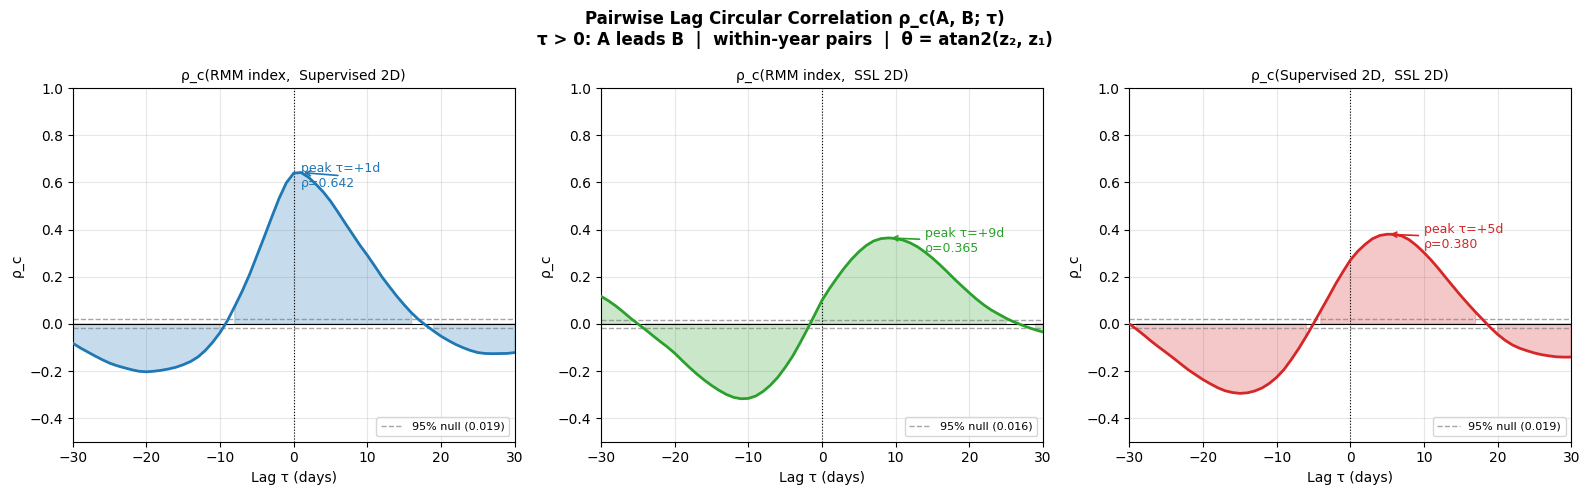

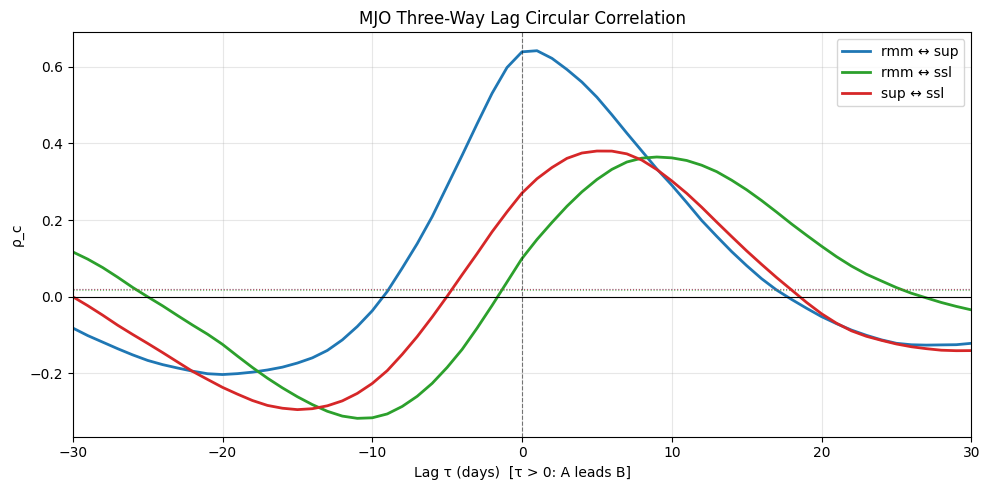

Saved: lag_circular_corr.png, lag_circular_corr_overlay.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pairwise Lag Circular Correlation ρ_c(A, B; τ)\n'
             'τ > 0: A leads B  |  within-year pairs  |  θ = atan2(z₂, z₁)'
             + (' (SSL z₂ negated for orientation)' if SSL_FLIP else ''),
             fontsize=12, fontweight='bold')

panels = [
    (rho_rmm_sup, null_rmm_sup, n_rmm_sup, 'ρ_c(RMM index,  Supervised 2D)', '#1f77b4'),
    (rho_rmm_ssl, null_rmm_ssl, n_rmm_ssl, 'ρ_c(RMM index,  SSL 2D)',         '#2ca02c'),
    (rho_sup_ssl, null_sup_ssl, n_sup_ssl, 'ρ_c(Supervised 2D,  SSL 2D)',      '#d62728'),
]

for ax, (rho, nb, npairs, title, color) in zip(axes, panels):
    ax.plot(lags, rho, color=color, lw=2, zorder=3)
    ax.fill_between(lags, rho, 0, where=np.abs(rho) > nb, color=color, alpha=0.25, zorder=2)
    ax.axhline( nb, color='gray', ls='--', lw=1, alpha=0.7, label=f'95% null ({nb:.3f})')
    ax.axhline(-nb, color='gray', ls='--', lw=1, alpha=0.7)
    ax.axhline(0,   color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8, ls=':')
    peak = np.nanargmax(rho)
    ax.annotate(f'peak τ={lags[peak]:+d}d\nρ={rho[peak]:.3f}',
                xy=(lags[peak], rho[peak]),
                xytext=(lags[peak] + 5*np.sign(lags[peak] - 1), rho[peak] - 0.06),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Lag τ (days)'); ax.set_ylabel('ρ_c')
    ax.set_xlim(-MAX_LAG, MAX_LAG); ax.set_ylim(-0.5, 1.0)
    ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lag_circular_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlay version
fig, ax = plt.subplots(figsize=(10, 5))
for rho, nb, label, color in [
    (rho_rmm_sup, null_rmm_sup, 'rmm ↔ sup', '#1f77b4'),
    (rho_rmm_ssl, null_rmm_ssl, 'rmm ↔ ssl', '#2ca02c'),
    (rho_sup_ssl, null_sup_ssl, 'sup ↔ ssl', '#d62728'),
]:
    ax.plot(lags, rho, color=color, lw=2, label=label)
    ax.axhline(nb, color=color, lw=0.8, ls=':', alpha=0.6)
ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Lag τ (days)  [τ > 0: A leads B]'); ax.set_ylabel('ρ_c')
ax.set_title('MJO Three-Way Lag Circular Correlation', fontsize=12)
ax.set_xlim(-MAX_LAG, MAX_LAG); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lag_circular_corr_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: lag_circular_corr.png, lag_circular_corr_overlay.png')

## Cell 5b — Autocorrelation Analysis (Temporal Self-Memory)

For each representation, compute the circular autocorrelation ρ_c(A(t), A(t+τ)) at lags τ ∈ [0, 30] days.

The **e-folding decorrelation time τ_e** is the first positive lag where ρ_auto drops to e⁻¹ ≈ 0.368.  
A longer τ_e means the representation retains memory of its own state further into the future — a proxy for the coherence timescale of the MJO signal captured by each method.

**Expected:** RMM τ_e ≈ 15–25 d (observed MJO coherence); if SSL τ_e differs substantially, it is tracking a different dynamical timescale (e.g. slower ENSO-modulated structure or faster noise).

In [ ]:
# Autocorrelation: ρ_c(A(t), A(t+τ)) for each representation
# Reuses precompute_pairs with A=B; permutation null shuffles within years.
print('Precomputing autocorrelation pair indices...')
t0 = time.time()
_, auto_pairs_rmm = precompute_pairs(dates_rmm, dates_rmm, max_lag=MAX_LAG)
_, auto_pairs_sup = precompute_pairs(dates_sup, dates_sup, max_lag=MAX_LAG)
_, auto_pairs_ssl = precompute_pairs(dates_ssl, dates_ssl, max_lag=MAX_LAG)
print(f'  Done in {time.time()-t0:.1f}s')

rho_auto_rmm, n_auto_rmm = lag_corr_from_pairs(theta_rmm, theta_rmm, lags, auto_pairs_rmm)
rho_auto_sup, n_auto_sup = lag_corr_from_pairs(theta_sup, theta_sup, lags, auto_pairs_sup)
rho_auto_ssl, n_auto_ssl = lag_corr_from_pairs(theta_ssl, theta_ssl, lags, auto_pairs_ssl)

# Null: within-year permutation destroys temporal ordering
print('Permutation nulls for autocorrelations...')
t0 = time.time()
null_auto_rmm = permutation_null_fast(theta_rmm, theta_rmm, dates_rmm, lags, auto_pairs_rmm, n_perm=N_PERM, rng=RNG)
null_auto_sup = permutation_null_fast(theta_sup, theta_sup, dates_sup, lags, auto_pairs_sup, n_perm=N_PERM, rng=RNG)
null_auto_ssl = permutation_null_fast(theta_ssl, theta_ssl, dates_ssl, lags, auto_pairs_ssl, n_perm=N_PERM, rng=RNG)
print(f'  rmm: 95th null |ρ| = {null_auto_rmm:.3f}  ({time.time()-t0:.1f}s)')
print(f'  sup: 95th null |ρ| = {null_auto_sup:.3f}')
print(f'  ssl: 95th null |ρ| = {null_auto_ssl:.3f}')

def decorrelation_time(rho, lags, threshold=1.0/np.e):
    """First positive lag where ρ_auto drops at or below threshold (e-folding timescale)."""
    for tau, r in zip(lags[lags > 0], rho[lags > 0]):
        if not np.isnan(r) and r <= threshold:
            return int(tau)
    return int(lags[-1]) + 1   # still above threshold at MAX_LAG

tau_e_rmm = decorrelation_time(rho_auto_rmm, lags)
tau_e_sup = decorrelation_time(rho_auto_sup, lags)
tau_e_ssl = decorrelation_time(rho_auto_ssl, lags)

print(f'\nAutocorrelation summary  (τ > 0; τ=0 is always 1.0 by definition):')
print(f'{"Rep":<8s}  {"ρ(τ=1)":>8s}  {"ρ(τ=5)":>8s}  {"ρ(τ=10)":>8s}  {"ρ(τ=20)":>8s}  {"τ_e":>8s}')
for rep, rho, tau_e in [('rmm', rho_auto_rmm, tau_e_rmm),
                         ('sup', rho_auto_sup, tau_e_sup),
                         ('ssl', rho_auto_ssl, tau_e_ssl)]:
    def g(t):
        idx = np.where(lags == t)[0]
        return f'{rho[idx[0]]:.3f}' if len(idx) and not np.isnan(rho[idx[0]]) else '  n/a'
    print(f'{rep:<8s}  {g(1):>8s}  {g(5):>8s}  {g(10):>8s}  {g(20):>8s}  {str(tau_e)+"d":>8s}')

## Cell 5c — Plot Autocorrelations

In [ ]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('MJO Circular Autocorrelation ρ_c(A(t), A(t+τ))\n'
             'τ ≥ 0 only  |  within-year pairs  |  shaded = above 95% null',
             fontsize=12, fontweight='bold')

e_fold   = 1.0 / np.e
pos_mask = lags >= 0
lags_pos = lags[pos_mask]

# Left: overlay of all three autocorrelation curves
for rho, nb, label, color in [
    (rho_auto_rmm, null_auto_rmm, f'RMM  (τ_e = {tau_e_rmm}d)',        '#1f77b4'),
    (rho_auto_sup, null_auto_sup, f'Supervised  (τ_e = {tau_e_sup}d)', '#d62728'),
    (rho_auto_ssl, null_auto_ssl, f'SSL  (τ_e = {tau_e_ssl}d)',         '#2ca02c'),
]:
    ax_left.plot(lags_pos, rho[pos_mask], color=color, lw=2, label=label)
    ax_left.fill_between(lags_pos, rho[pos_mask], e_fold,
                         where=rho[pos_mask] >= e_fold,
                         color=color, alpha=0.15, interpolate=True)
    ax_left.axhline(nb, color=color, lw=0.8, ls=':', alpha=0.6)

ax_left.axhline(e_fold, color='gray', ls='--', lw=1.2,
                label=f'e⁻¹ ≈ {e_fold:.2f}  (e-folding threshold)')
ax_left.axhline(0, color='k', lw=0.6)
ax_left.set_xlabel('Lag τ (days)'); ax_left.set_ylabel('ρ_c')
ax_left.set_title('Autocorrelation Overlay', fontsize=11)
ax_left.set_xlim(0, MAX_LAG); ax_left.set_ylim(-0.15, 1.05)
ax_left.legend(fontsize=9); ax_left.grid(True, alpha=0.3)

# Right: bar chart of e-folding decorrelation times
tau_vals   = [tau_e_rmm, tau_e_sup, tau_e_ssl]
bar_labels = ['RMM\n(conventional)', 'Supervised\n(nb14)', 'SSL\n(nb15)']
bar_colors = ['#1f77b4', '#d62728', '#2ca02c']
bars = ax_right.bar(bar_labels, tau_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, tau_vals):
    ax_right.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                  f'{v}d', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_right.set_ylabel('e-folding time τ_e (days)')
ax_right.set_title('Temporal Memory: e-Folding Decorrelation Time', fontsize=11)
ax_right.set_ylim(0, max(tau_vals) * 1.3 + 2)
ax_right.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: autocorrelation.png')

## Cell 6 — Per-Phase ENSO Displacement Z-Scores (3 Reps × 8 Phases)

For each representation, sector its angles into 8 octants (or use the discrete `phase` column for RMM), then compute EN−LN displacement per sector with permutation null.  
**The key test:** does SSL show larger displacements than RMM/sup?

PER-PHASE ENSO DISPLACEMENT (active MJO only, 1000 permutations)
Rep          obs_mu    null_mu    null_sd    z-score
rmm          0.0769     0.0430     0.0083       4.10
sup          0.0509     0.0152     0.0029      12.21
ssl          0.1269     0.0357     0.0068      13.44


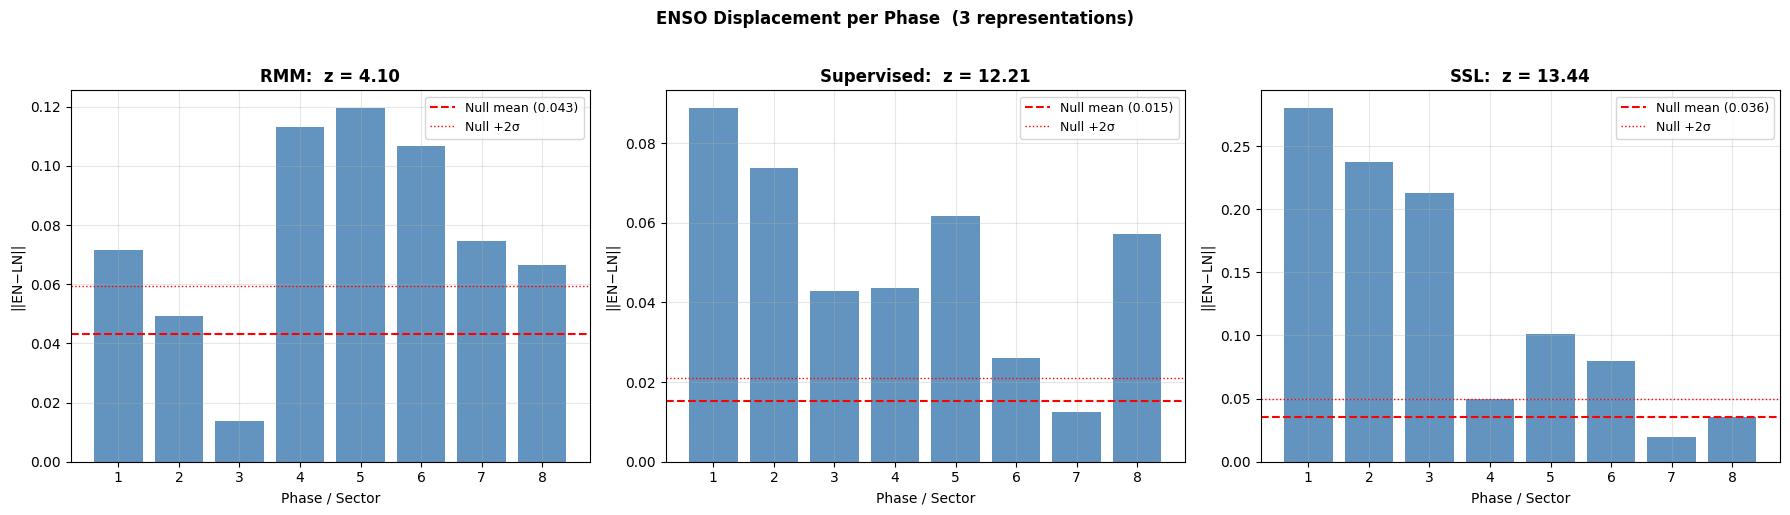

Saved: enso_displacement_3way.png


In [6]:
def angle_to_sector(theta):
    """Map angle (rad) ∈ (-π, π] to sector 1..8 in 45° bins. Sector 1 = (-π, -3π/4]."""
    deg = np.degrees(theta) + 180  # → [0, 360)
    return ((deg // 45).astype(int) % 8) + 1

def compute_displacement_zscore(emb, sectors, enso, n_perm=1000, rng=None):
    """Per-sector ||EN-LN|| means + permutation null z-score (rep-level)."""
    if rng is None: rng = np.random.default_rng(42)
    sectors = np.asarray(sectors); enso = np.asarray(enso)
    disp = np.full(8, np.nan)
    for s in range(1, 9):
        mEN = (sectors == s) & (enso == 'El Nino')
        mLN = (sectors == s) & (enso == 'La Nina')
        if mEN.sum() < 3 or mLN.sum() < 3: continue
        disp[s-1] = np.linalg.norm(emb[mEN].mean(axis=0) - emb[mLN].mean(axis=0))
    obs_mu = float(np.nanmean(disp))

    null = []
    for _ in range(n_perm):
        shuf = enso[rng.permutation(len(enso))]
        d = []
        for s in range(1, 9):
            mEN = (sectors == s) & (shuf == 'El Nino')
            mLN = (sectors == s) & (shuf == 'La Nina')
            if mEN.sum() < 3 or mLN.sum() < 3: continue
            d.append(np.linalg.norm(emb[mEN].mean(axis=0) - emb[mLN].mean(axis=0)))
        if d: null.append(np.mean(d))
    bmu = float(np.mean(null)); bsd = float(np.std(null))
    z = float((obs_mu - bmu) / (bsd + 1e-8))
    return disp, obs_mu, bmu, bsd, z

# RMM: use embeddings = (rmm1, rmm2), discrete phase column
emb_rmm = np.stack([df_rmm['rmm1'].values, df_rmm['rmm2'].values], axis=1)
act_rmm = (~df_rmm['weak_mjo'].values) & (df_rmm['phase'].between(1, 8).values)
disp_rmm, mu_rmm, b_rmm, s_rmm, z_rmm = compute_displacement_zscore(
    emb_rmm[act_rmm], df_rmm.loc[act_rmm, 'phase'].values,
    df_rmm.loc[act_rmm, 'enso_category'].values, n_perm=1000)

# Supervised: embeddings from nb14, sectors from atan2(z2, z1)
sec_sup = angle_to_sector(theta_sup)
act_sup = (~df_sup['weak_mjo'].values) & (df_sup['phase'].between(1, 8).values)
disp_sup, mu_sup, b_sup, s_sup, z_sup = compute_displacement_zscore(
    emb_sup[act_sup], sec_sup[act_sup],
    df_sup.loc[act_sup, 'enso_category'].values, n_perm=1000)

# SSL: embeddings from nb15 (apply z₂ flip if needed), sectors from theta_ssl
emb_ssl_use = emb_ssl.copy()
if SSL_FLIP: emb_ssl_use[:, 1] = -emb_ssl_use[:, 1]
sec_ssl = angle_to_sector(theta_ssl)
act_ssl = (~df_ssl['weak_mjo'].values) & (df_ssl['phase'].between(1, 8).values)
disp_ssl, mu_ssl, b_ssl, s_ssl, z_ssl = compute_displacement_zscore(
    emb_ssl_use[act_ssl], sec_ssl[act_ssl],
    df_ssl.loc[act_ssl, 'enso_category'].values, n_perm=1000)

print('=' * 80)
print('PER-PHASE ENSO DISPLACEMENT (active MJO only, 1000 permutations)')
print('=' * 80)
print(f'{"Rep":<8s} {"obs_mu":>10s} {"null_mu":>10s} {"null_sd":>10s} {"z-score":>10s}')
for rep, (mu, b, s, z) in [('rmm', (mu_rmm, b_rmm, s_rmm, z_rmm)),
                            ('sup', (mu_sup, b_sup, s_sup, z_sup)),
                            ('ssl', (mu_ssl, b_ssl, s_ssl, z_ssl))]:
    print(f'{rep:<8s} {mu:>10.4f} {b:>10.4f} {s:>10.4f} {z:>10.2f}')

# Plot per-phase bars (one panel per rep)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (rep, disp, b, s, z) in zip(axes, [
    ('RMM',        disp_rmm, b_rmm, s_rmm, z_rmm),
    ('Supervised', disp_sup, b_sup, s_sup, z_sup),
    ('SSL',        disp_ssl, b_ssl, s_ssl, z_ssl)]):
    phases = np.arange(1, 9)
    valid = ~np.isnan(disp)
    ax.bar(phases[valid], disp[valid], color='steelblue', alpha=0.85)
    ax.axhline(b, color='red', ls='--', lw=1.5, label=f'Null mean ({b:.3f})')
    ax.axhline(b + 2*s, color='red', ls=':', lw=1, label='Null +2σ')
    ax.set_xticks(phases); ax.set_xlabel('Phase / Sector')
    ax.set_ylabel('||EN−LN||')
    ax.set_title(f'{rep}:  z = {z:.2f}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('ENSO Displacement per Phase  (3 representations)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/enso_displacement_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: enso_displacement_3way.png')

## Cell 7 — Phase Composite Longitude Profiles (OLR' per representation)

For each representation × each phase/sector, compute the mean OLR' anomaly profile (longitude axis). Expected pattern: eastward-propagating convective envelope, OLR minimum shifting east as phase increases.

Uses **Lee-preprocessed `X_MJO.npy`** (not bandpassed) for all three reps so the only difference is the phase/sector assignment.

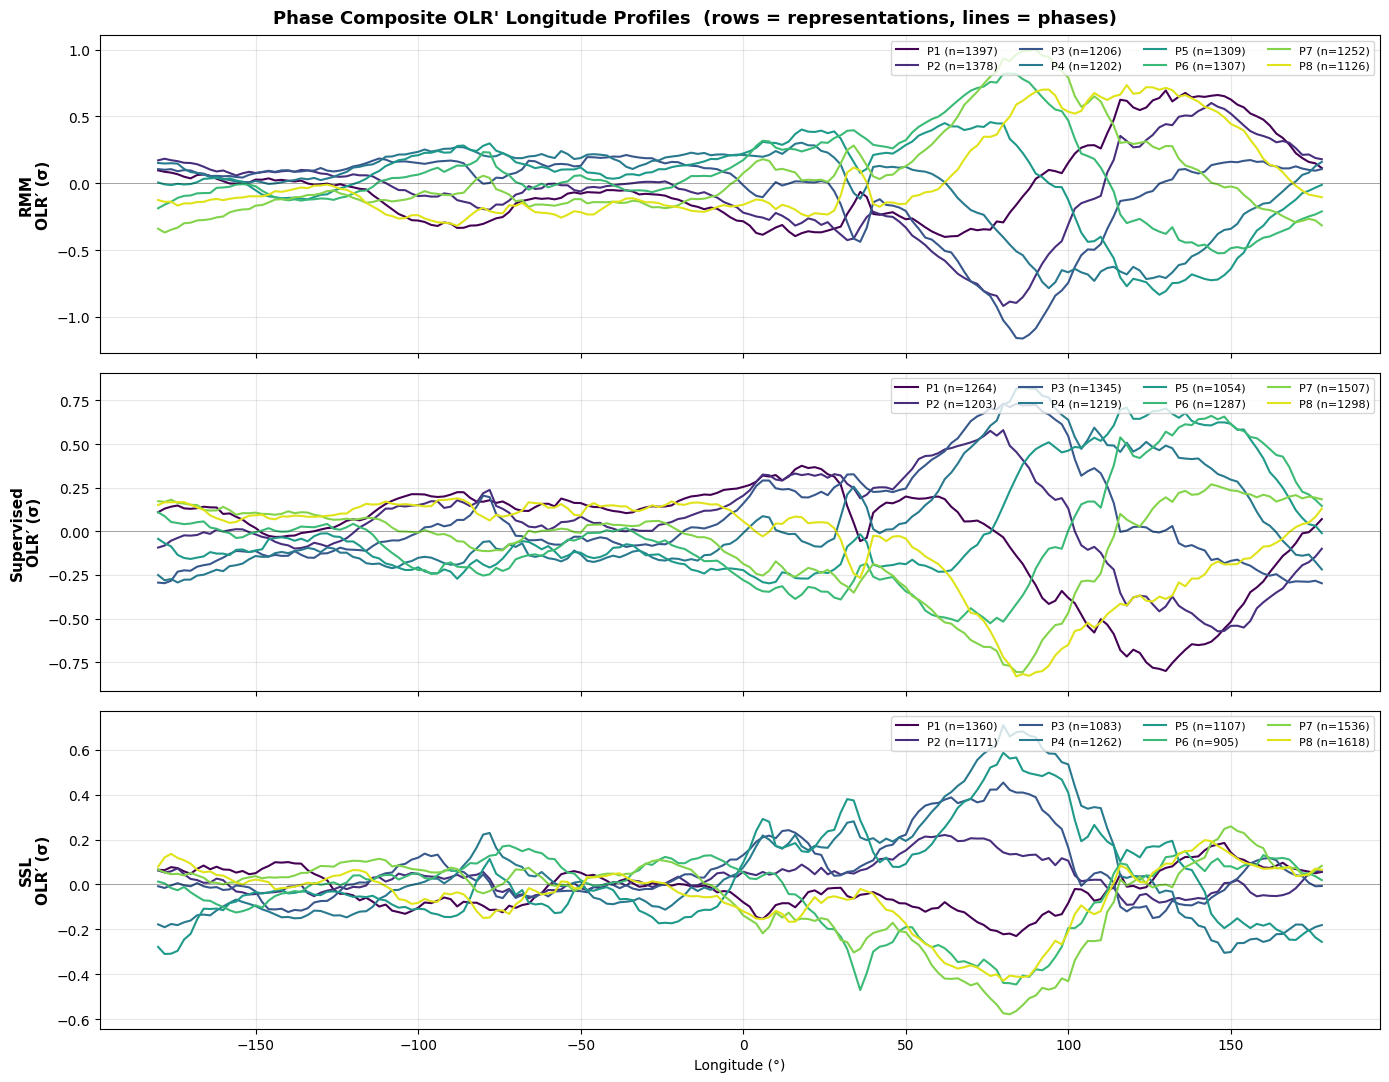

Saved: phase_composites_olr.png


In [7]:
X_full = np.load(X_FILE)   # (N_full, 3, 1, 180), channels [u850, OLR, u200]
lons   = np.load(LON_FILE)

# Build maps from each rep's date → X_full row index
date_to_xrow = {d: i for i, d in enumerate(df_sup['date'].values)}   # X_full aligned to df_sup

rep_specs = [
    ('RMM',        df_rmm['phase'].values, df_rmm['date'].values, df_rmm['weak_mjo'].values),
    ('Supervised', sec_sup,                df_sup['date'].values, df_sup['weak_mjo'].values),
    ('SSL',        sec_ssl,                df_ssl['date'].values, df_ssl['weak_mjo'].values),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Phase Composite OLR' Longitude Profiles  (rows = representations, lines = phases)",
             fontsize=13, fontweight='bold')

phase_colors = plt.cm.viridis(np.linspace(0, 0.95, 8))

for ax, (rep_name, sectors, dates_, weak) in zip(axes, rep_specs):
    for s in range(1, 9):
        # Get dates assigned to this phase/sector AND active MJO
        active_mask = (sectors == s) & (~weak)
        sel_dates = dates_[active_mask]
        # Map to X_full rows (skip dates not in X_full)
        rows = [date_to_xrow[d] for d in sel_dates if d in date_to_xrow]
        if len(rows) == 0: continue
        olr_comp = X_full[rows, 1, 0, :].mean(axis=0)   # channel 1 = OLR
        ax.plot(lons, olr_comp, color=phase_colors[s-1], lw=1.5, label=f'P{s} (n={len(rows)})')
    ax.axhline(0, color='k', lw=0.5, alpha=0.4)
    ax.set_ylabel(f'{rep_name}\nOLR′ (σ)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, ncol=4, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Longitude (°)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/phase_composites_olr.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: phase_composites_olr.png')

## Cell 8 — EN−LN Difference Composites (Key Result)

For each representation × each phase, compute the difference between the OLR' composite for El Niño days and La Niña days. If SSL shows stronger or more spatially-organized EN−LN structure than RMM/sup, that's the headline finding.

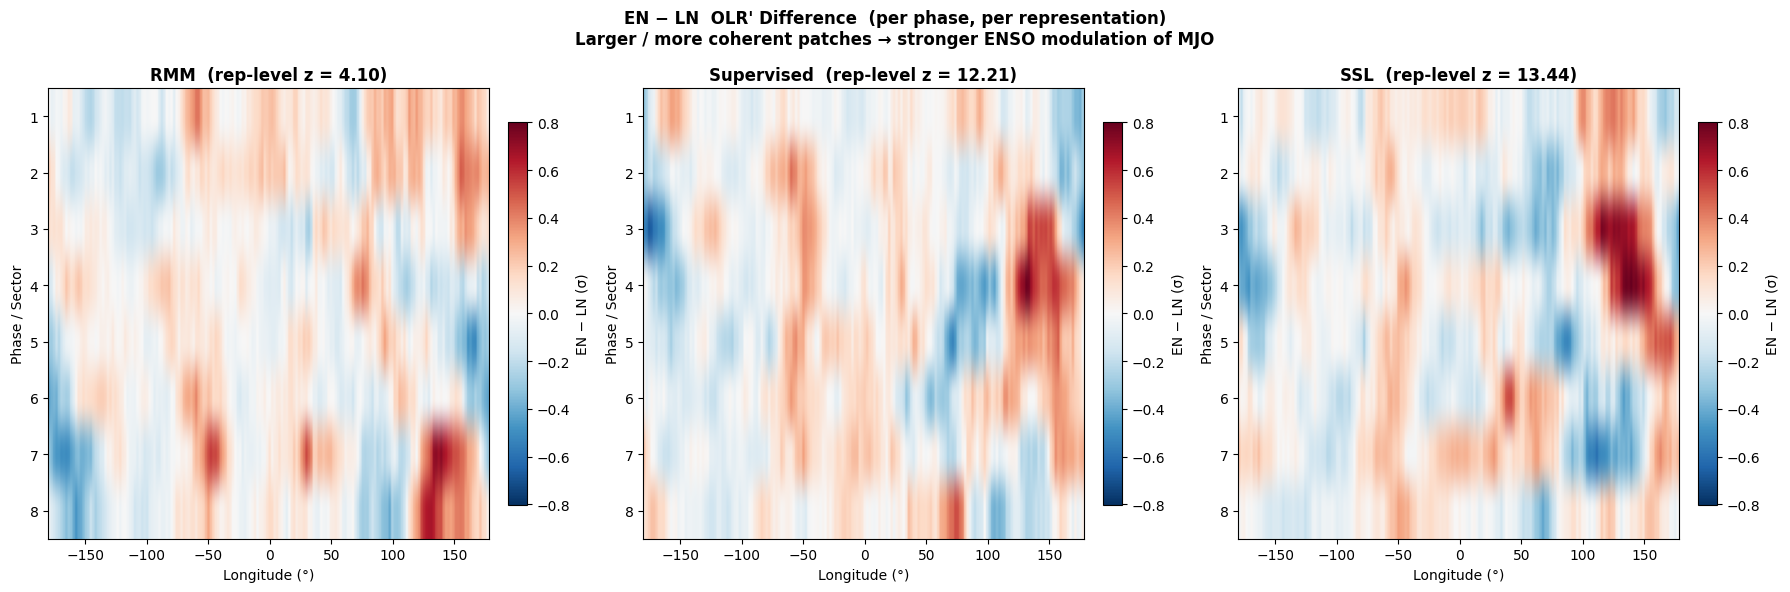

Saved: enln_difference_composites.png

Max |EN−LN| in OLR composites (σ units):
  RMM        : 0.723σ
  Supervised : 0.790σ
  SSL        : 0.802σ


In [8]:
def get_enln_diff_profile(sectors, dates_, enso, weak, channel=1):
    """Returns (8, n_lon) array of EN-LN OLR' difference per phase."""
    diff = np.full((8, len(lons)), np.nan)
    for s in range(1, 9):
        base = (sectors == s) & (~weak)
        d_en = dates_[base & (enso == 'El Nino')]
        d_ln = dates_[base & (enso == 'La Nina')]
        rows_en = [date_to_xrow[d] for d in d_en if d in date_to_xrow]
        rows_ln = [date_to_xrow[d] for d in d_ln if d in date_to_xrow]
        if len(rows_en) < 3 or len(rows_ln) < 3: continue
        diff[s-1] = X_full[rows_en, channel, 0, :].mean(axis=0) - X_full[rows_ln, channel, 0, :].mean(axis=0)
    return diff

diff_rmm = get_enln_diff_profile(df_rmm['phase'].values, df_rmm['date'].values,
                                   df_rmm['enso_category'].values, df_rmm['weak_mjo'].values)
diff_sup = get_enln_diff_profile(sec_sup, df_sup['date'].values,
                                   df_sup['enso_category'].values, df_sup['weak_mjo'].values)
diff_ssl = get_enln_diff_profile(sec_ssl, df_ssl['date'].values,
                                   df_ssl['enso_category'].values, df_ssl['weak_mjo'].values)

# Heatmaps: rows = sector/phase 1-8, cols = longitude. One panel per rep.
vmax = max(np.nanmax(np.abs(d)) for d in [diff_rmm, diff_sup, diff_ssl])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("EN − LN  OLR' Difference  (per phase, per representation)\n"
             'Larger / more coherent patches → stronger ENSO modulation of MJO',
             fontsize=12, fontweight='bold')

for ax, (rep, d, z) in zip(axes,
                            [('RMM',        diff_rmm, z_rmm),
                             ('Supervised', diff_sup, z_sup),
                             ('SSL',        diff_ssl, z_ssl)]):
    im = ax.imshow(d, cmap='RdBu_r', aspect='auto',
                   extent=[lons.min(), lons.max(), 8.5, 0.5],
                   vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(1, 9))
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Phase / Sector')
    ax.set_title(f'{rep}  (rep-level z = {z:.2f})', fontweight='bold')
    plt.colorbar(im, ax=ax, label='EN − LN (σ)', fraction=0.04, pad=0.04)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/enln_difference_composites.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: enln_difference_composites.png')

# Quick numerical summary: max |EN-LN| per rep
print('\nMax |EN−LN| in OLR composites (σ units):')
for rep, d in [('RMM', diff_rmm), ('Supervised', diff_sup), ('SSL', diff_ssl)]:
    print(f'  {rep:<11s}: {np.nanmax(np.abs(d)):.3f}σ')

## Cell 9 — Comparison Report (Auto-Generated)

In [ ]:
import time as _t

# Determine SSL advantage status
ssl_advantage_vs_sup = z_ssl > z_sup
ssl_advantage_vs_rmm = z_ssl > z_rmm

report_lines = [
    '=' * 75,
    'MJO THREE-WAY COMPARISON REPORT',
    f'Date: {_t.strftime("%Y-%m-%d")}',
    '=' * 75,
    '',
    'Representations:',
    f'  rmm  — Wheeler & Hendon RMM index           N = {len(theta_rmm)} days',
    f'  sup  — Supervised 2D encoder (nb14)         N = {len(theta_sup)} days',
    f'  ssl  — SSL temporal 2D encoder (nb15)       N = {len(theta_ssl)} days',
    f'  SSL orientation: {"z₂ negated" if SSL_FLIP else "unflipped"}',
    '',
    'LAG CIRCULAR CORRELATION',
    '-' * 75,
]
for name, rho, n, nb in [
    ('rmm↔sup', rho_rmm_sup, n_rmm_sup, null_rmm_sup),
    ('rmm↔ssl', rho_rmm_ssl, n_rmm_ssl, null_rmm_ssl),
    ('sup↔ssl', rho_sup_ssl, n_sup_ssl, null_sup_ssl),
]:
    peak = np.nanargmax(rho)
    report_lines += [
        f'  {name}:  ρ(τ=0)={rho[lags==0][0]:+.3f}   '
        f'peak ρ={rho[peak]:+.3f} at τ={lags[peak]:+d}d   '
        f'95% null |ρ|={nb:.3f}'
    ]

report_lines += [
    '',
    'AUTOCORRELATION (e-folding decorrelation timescale; τ_e at ρ = e⁻¹ ≈ 0.368)',
    '-' * 75,
    f'  RMM         : τ_e = {tau_e_rmm}d   '
    f'ρ(τ=1)={rho_auto_rmm[lags==1][0]:.3f}  '
    f'ρ(τ=10)={rho_auto_rmm[lags==10][0]:.3f}  '
    f'ρ(τ=20)={rho_auto_rmm[lags==20][0]:.3f}',
    f'  Supervised  : τ_e = {tau_e_sup}d   '
    f'ρ(τ=1)={rho_auto_sup[lags==1][0]:.3f}  '
    f'ρ(τ=10)={rho_auto_sup[lags==10][0]:.3f}  '
    f'ρ(τ=20)={rho_auto_sup[lags==20][0]:.3f}',
    f'  SSL         : τ_e = {tau_e_ssl}d   '
    f'ρ(τ=1)={rho_auto_ssl[lags==1][0]:.3f}  '
    f'ρ(τ=10)={rho_auto_ssl[lags==10][0]:.3f}  '
    f'ρ(τ=20)={rho_auto_ssl[lags==20][0]:.3f}',
    '  (Observed MJO coherence: τ_e ≈ 15–25 d for a well-resolved index)',
    '',
    'ENSO DISPLACEMENT Z-SCORES (1000 permutations, active MJO only)',
    '-' * 75,
    f'  RMM         : z = {z_rmm:+.2f}   (observed {mu_rmm:.4f}, null {b_rmm:.4f}±{s_rmm:.4f})',
    f'  Supervised  : z = {z_sup:+.2f}   (observed {mu_sup:.4f}, null {b_sup:.4f}±{s_sup:.4f})',
    f'  SSL         : z = {z_ssl:+.2f}   (observed {mu_ssl:.4f}, null {b_ssl:.4f}±{s_ssl:.4f})',
    '',
    'EN − LN OLR\' COMPOSITE max |Δ| (σ units, peak ENSO modulation amplitude)',
    '-' * 75,
    f'  RMM         : {np.nanmax(np.abs(diff_rmm)):.3f}σ',
    f'  Supervised  : {np.nanmax(np.abs(diff_sup)):.3f}σ',
    f'  SSL         : {np.nanmax(np.abs(diff_ssl)):.3f}σ',
    '',
    'BSISO REFERENCE (for context)',
    '-' * 75,
    '  64D supervised:           phase 67.7%, z 3.83',
    '  2D supervised (nb07c):    phase 58.3%, z 2.53',
    '  2D SSL temporal (nb08):   phase ~30-40%, z 14.55  ← SSL advantage',
    '',
    'HEADLINE COMPARISON',
    '-' * 75,
    f'  SSL advantage over Supervised:   z_SSL ({z_ssl:.2f}) {"  > " if ssl_advantage_vs_sup else " <= "}  z_sup ({z_sup:.2f})',
    f'  SSL advantage over RMM:          z_SSL ({z_ssl:.2f}) {"  > " if ssl_advantage_vs_rmm else " <= "}  z_rmm ({z_rmm:.2f})',
    '',
]

if ssl_advantage_vs_sup and ssl_advantage_vs_rmm:
    report_lines += [
        'INTERPRETATION:',
        '  SSL captures ENSO modulation more strongly than both the conventional',
        '  RMM index and the supervised encoder. This parallels the BSISO finding',
        '  (z_SSL=14.55 vs z_sup=2.53) and suggests the SSL advantage is a general',
        '  property of temporal contrastive learning on intraseasonal atmospheric data,',
        '  not specific to boreal summer monsoon dynamics.',
    ]
elif z_ssl > 5:
    report_lines += [
        'INTERPRETATION:',
        f'  SSL captures significant ENSO emergence (z={z_ssl:.2f}) without labels,',
        f'  but does not exceed all other representations. Document as a confirmatory result.',
    ]
else:
    report_lines += [
        'INTERPRETATION:',
        f'  ENSO modulation in SSL (z={z_ssl:.2f}) is weaker than expected from BSISO analog.',
        '  Possible explanations: (a) MJO all-year data has stronger seasonal confound;',
        '  (b) bandpass design needs tightening; (c) MJO is less ENSO-modulated at the',
        '  intraseasonal scale than BSISO. Inspect month-clustering check in nb15.',
    ]

report_lines += [
    '',
    'OUTPUT FILES',
    '-' * 75,
    '  lag_circular_corr.png             — 3-panel pairwise lag correlation',
    '  lag_circular_corr_overlay.png     — overlay of all three cross-correlation curves',
    '  autocorrelation.png               — e-folding timescales + autocorrelation overlay',
    '  enso_displacement_3way.png        — per-phase ENSO displacement bars',
    '  phase_composites_olr.png          — OLR\' longitude profiles per phase',
    '  enln_difference_composites.png    — EN−LN difference heatmaps (KEY)',
    '  mjo_comparison_report.txt         — this report',
    '=' * 75,
]

report_text = '\n'.join(report_lines)
print(report_text)

with open(f'{OUT_DIR}/mjo_comparison_report.txt', 'w') as f:
    f.write(report_text)
print(f'\nSaved: {OUT_DIR}/mjo_comparison_report.txt')

# Numerical summary CSV (now includes tau_e_days)
df_summary = pd.DataFrame([
    {'rep': 'rmm', 'rho_tau0_with_rmm': 1.0,
     'z_score': z_rmm, 'max_enln_olr_sigma': float(np.nanmax(np.abs(diff_rmm))),
     'tau_e_days': tau_e_rmm},
    {'rep': 'sup', 'rho_tau0_with_rmm': float(rho_rmm_sup[lags==0][0]),
     'z_score': z_sup, 'max_enln_olr_sigma': float(np.nanmax(np.abs(diff_sup))),
     'tau_e_days': tau_e_sup},
    {'rep': 'ssl', 'rho_tau0_with_rmm': float(rho_rmm_ssl[lags==0][0]),
     'z_score': z_ssl, 'max_enln_olr_sigma': float(np.nanmax(np.abs(diff_ssl))),
     'tau_e_days': tau_e_ssl},
])
df_summary.to_csv(f'{OUT_DIR}/mjo_comparison_summary.csv', index=False)
print(f'Saved: {OUT_DIR}/mjo_comparison_summary.csv')
print(df_summary.to_string(index=False))

## Cell 10 — (Optional) Download All Outputs

In [10]:
from google.colab import files
for fname in sorted(os.listdir(OUT_DIR)):
    files.download(f'{OUT_DIR}/{fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

MJO extension is now functionally complete. Files produced by this notebook:

```
BSISO_SSL_Project/MJO/results/comparison/
├── lag_circular_corr.png            ← 3-panel pairwise lag correlation
├── lag_circular_corr_overlay.png    ← overlay of all three cross-correlation curves
├── autocorrelation.png              ← e-folding timescales + autocorrelation overlay (NEW)
├── enso_displacement_3way.png       ← per-phase ENSO displacement bars
├── phase_composites_olr.png         ← phase composite OLR' longitude profiles
├── enln_difference_composites.png   ← EN−LN difference heatmaps (the key figure)
├── mjo_comparison_report.txt        ← auto-generated comparison report
└── mjo_comparison_summary.csv       ← numerical summary (rep, rho, z, max_enln, tau_e_days)
```

**Send back:**
1. `mjo_comparison_report.txt` — headline numbers and interpretation
2. `enln_difference_composites.png` — key visual
3. `lag_circular_corr.png` — how the three representations relate
4. `enso_displacement_3way.png` — per-phase z-score comparison
5. `autocorrelation.png` — temporal memory / decorrelation timescales

---
*DDCS Project | jh9141@nyu.edu*